In [1532]:
# import all libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import math
import random

np.random.seed(42)

In [1533]:
# load csv
base_df = pd.read_csv('C:/CMI-DataScience-Project/atp_transformed/2000-2024 players_3.csv')

C:\Users\Golbe\AppData\Local\Temp\ipykernel_4340\4063985396.py:2: DtypeWarning: Columns (18,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  base_df = pd.read_csv('C:/CMI-DataScience-Project/atp_transformed/2000-2024 players_3.csv')


In [1534]:
# In case you do not know the id associated with a player you can insert a full name or part of a name in this lookup tool
player_name = 'Andy Mur'

base_df[['player_name','player_id','player_country','tourney_name','tourney_date','player_rank','elo']][base_df['player_name'].str.contains(player_name)]

,player_name,player_id,player_country,tourney_name,tourney_date,player_rank,elo
502391,Andy Murray,104918,GBR,Manchester CH,2003-07-14,2268.0,1528.306334
502392,Andy Murray,104918,GBR,Manchester CH,2003-07-14,2268.0,1551.513540
502393,Andy Murray,104918,GBR,Manchester CH,2003-07-14,2268.0,1538.232725
502394,Andy Murray,104918,GBR,Segovia CH,2003-07-28,774.0,1532.552570
502395,Andy Murray,104918,GBR,Great Britain F7,2003-08-04,754.0,1511.131057
...,...,...,...,...,...,...,...
503508,Andy Murray,104918,GBR,Geneva,2024-05-20,75.0,2208.602937
503509,Andy Murray,104918,GBR,Roland Garros,2024-05-27,75.0,2189.160663
503510,Andy Murray,104918,GBR,Stuttgart,2024-06-10,97.0,2171.686429
503511,Andy Murray,104918,GBR,Queen's Club,2024-06-17,129.0,2190.230666


## IMPORTANT!!!
DISABLE THE PLAYER HERE. IF NO PLAYER_ID IS PASSED IT WILL USE THE WHOLE DATASET

In [1535]:
# put the player id of the player you want to exclude here and decide whether you want to treat him as a completely new player or not by setting holdout to true
excluded_player = 121264
holdout = True

only_players = base_df[['player_name','player_id']]
only_players = only_players.drop_duplicates()

if excluded_player != 0:
    name_chosen_player = only_players['player_name'][only_players['player_id'] == excluded_player].iloc[0]

## Rest of normal flow

In [1536]:
# choose the cutoff in years of experience
years_cutoff = 3

# convert to days of experience
day_cutoff = years_cutoff * 365.25

# optionally choose up to what number of years the model wil predict (the cut off point for testing the rank)
max_years_cutoff = 0
max_number_of_days_cutoff = max_years_cutoff * 365.25

In [1537]:
# extra assignment to reset dataframe if a mistake is made during processing
full_df = base_df.copy()
len(full_df)

1282807

In [1538]:
selected_features = [
'player_id', # needed to know what player to keep or drop
'tourney_level', 
'match_num', 
'player_age', 
'days_of_experience',
'draw_size_rolling_med_10', 
'highest_finish_position_rolling_med_10', 
'set_dominance_rolling_mean_10', 
'tb_dominance_rolling_mean_10', 
'mean_numb_rolling_mean_10', 
'mean_diff_rolling_mean_10', 
'mean_tb_numb_rolling_mean_10', 
'mean_tb_diff_rolling_mean_10', 
 'elo', # This is the elo after the match has concluded and is the same as elo post match
'binned_elo' # target
]

In [1539]:
print(full_df.shape)

(1282807, 132)


replace all nan values with 0

In [1540]:
full_df[['median_tb_diff','mean_tb_numb','median_tb_numb','mean_tb_diff','tb_dominance',
         'draw_size_rolling_med_10', 'highest_finish_position_rolling_med_10', 'ace_rolling_mean_10', 
        'double_faults_rolling_mean_10', 'points_on_serve_rolling_mean_10', 'first_serve_in_rolling_mean_10',
        '1stWon_rolling_mean_10', '2ndWon_rolling_mean_10', 'service_games_rolling_mean_10', 'break_points_saved_rolling_mean_10',
        'break_points_faced_rolling_mean_10','elo_pre_match_rolling_mean_10','opponent_elo_pre_match_rolling_mean_10', 
        'set_dominance_rolling_mean_10','tb_dominance_rolling_mean_10','player_rank_rolling_mean_10', 'mean_numb_rolling_mean_10', 
        'median_numb_rolling_mean_10','total_numb_rolling_mean_10','mean_diff_rolling_mean_10','median_diff_rolling_mean_10', 
        'total_diff_rolling_mean_10','mean_tb_numb_rolling_mean_10','median_tb_numb_rolling_mean_10','total_tb_numb_rolling_mean_10', 
        'mean_tb_diff_rolling_mean_10','median_tb_diff_rolling_mean_10','total_tb_diff_rolling_mean_10']] = full_df[['median_tb_diff','mean_tb_numb','median_tb_numb','mean_tb_diff','tb_dominance','draw_size_rolling_med_10', 'highest_finish_position_rolling_med_10', 'ace_rolling_mean_10', 
        'double_faults_rolling_mean_10', 'points_on_serve_rolling_mean_10', 'first_serve_in_rolling_mean_10',
        '1stWon_rolling_mean_10', '2ndWon_rolling_mean_10', 'service_games_rolling_mean_10', 'break_points_saved_rolling_mean_10',
        'break_points_faced_rolling_mean_10','elo_pre_match_rolling_mean_10','opponent_elo_pre_match_rolling_mean_10', 
        'set_dominance_rolling_mean_10','tb_dominance_rolling_mean_10','player_rank_rolling_mean_10', 'mean_numb_rolling_mean_10', 
        'median_numb_rolling_mean_10','total_numb_rolling_mean_10','mean_diff_rolling_mean_10','median_diff_rolling_mean_10', 
        'total_diff_rolling_mean_10','mean_tb_numb_rolling_mean_10','median_tb_numb_rolling_mean_10','total_tb_numb_rolling_mean_10', 
        'mean_tb_diff_rolling_mean_10','median_tb_diff_rolling_mean_10','total_tb_diff_rolling_mean_10']].replace(np.nan,0)

In [1541]:
# fill missing elo with baseline as that is where everything starts
print(full_df['elo'].isna().sum())
full_df['elo'] = full_df['elo'].replace(np.nan,1500)
print(full_df['elo'].isna().sum())

# also make one without nan values to compare
print(base_df['elo'].isna().sum())
full_df_2 = base_df[base_df['elo'].notna()]
print(full_df_2['elo'].isna().sum())

19267
0
19267
0


Create the max player elo and join to full_df as best elo reached

In [1542]:
full_df = full_df.sort_values(['player_id','days_of_experience'])

full_df['best_elo_reached'] = full_df.groupby('player_id')['elo'].transform('max')
full_df_2['best_elo_reached'] = full_df_2.groupby('player_id')['elo'].transform('max')

C:\Users\Golbe\AppData\Local\Temp\ipykernel_4340\1436156817.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_df_2['best_elo_reached'] = full_df_2.groupby('player_id')['elo'].transform('max')


## Binning logic

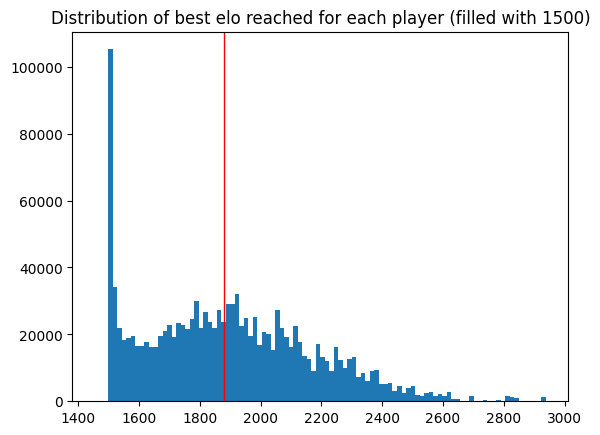

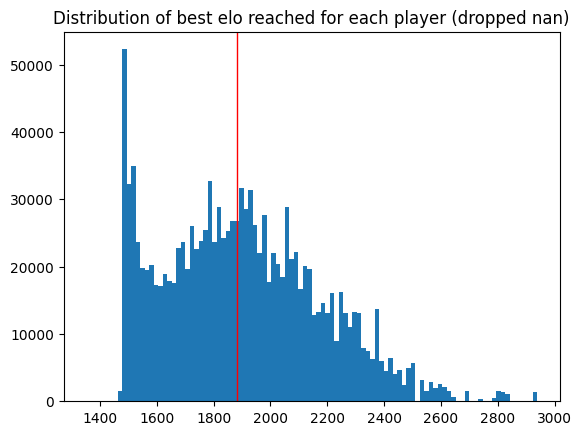

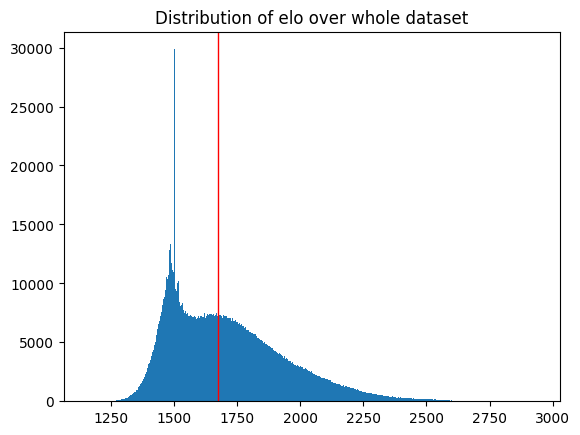

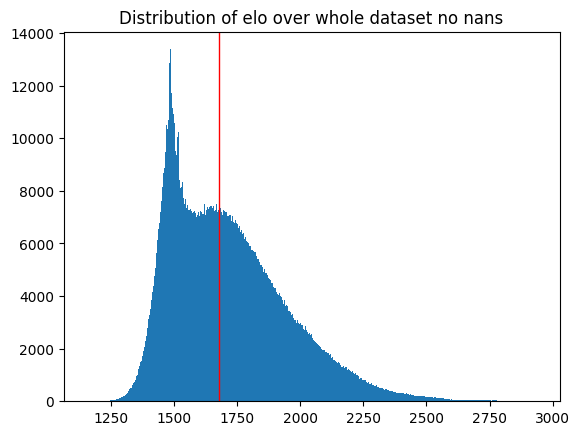

,full_df (filled NaN),full_df_2 (no NaN),population_difference,best_elo (filled NaN),best_elo (no NaN),best_elo_difference
count,1.282807e+06,1.263540e+06,-19267.0000,1.282807e+06,1.263540e+06,-19267.0000
mean,1.711800e+03,1.715030e+03,3.2296,1.896971e+03,1.901378e+03,4.4066
std,2.341727e+02,2.344751e+02,0.3024,2.787665e+02,2.781092e+02,-0.6574
min,1.150759e+03,1.150759e+03,0.0000,1.454307e+03,1.351583e+03,-102.7235
25%,1.517139e+03,1.523177e+03,6.0382,1.676627e+03,1.684955e+03,8.3277
50%,1.671911e+03,1.676642e+03,4.7310,1.877720e+03,1.883219e+03,5.4987
75%,1.850411e+03,1.853898e+03,3.4874,2.081984e+03,2.088072e+03,6.0874
max,2.938310e+03,2.938310e+03,0.0000,2.938310e+03,2.938310e+03,0.0000


In [1543]:
# histogram of the target var (very skewed because the minimum highest rank is 1500. It could be argued that the max ranks should only be all players who quit early stop at 1500 or lower)
plt.title("Distribution of best elo reached for each player (filled with 1500)")
plt.hist(full_df['best_elo_reached'],bins=100)
plt.axvline(np.quantile(full_df['best_elo_reached'],0.5),color='red',linewidth=1)
plt.show()

plt.title("Distribution of best elo reached for each player (dropped nan)")
plt.hist(full_df_2['best_elo_reached'],bins=100)
plt.axvline(np.quantile(full_df_2['best_elo_reached'],0.5),color='red',linewidth=1)
plt.show()

# histogram of the elo
plt.title("Distribution of elo over whole dataset")
plt.hist(full_df['elo'],bins=500)
plt.axvline(np.quantile(full_df['elo'],0.5),color='red',linewidth=1)
plt.show()

plt.title("Distribution of elo over whole dataset no nans")
plt.hist(full_df_2['elo'],bins=500)
plt.axvline(np.quantile(full_df_2['elo'],0.5),color='red',linewidth=1)
plt.show()

# make descriptve stats to show the difference is small when filling vs dropping for both populations and max rank feature
desc_filled = full_df['elo'].describe()
desc_dropped = full_df_2['elo'].describe()
desc_best_elo_filled = full_df['best_elo_reached'].describe()
desc_best_elo_dropped = full_df_2['best_elo_reached'].describe()


# Combine into one DataFrame
summary_df = pd.DataFrame({
    'full_df (filled NaN)': round(desc_filled,4),
    'full_df_2 (no NaN)': round(desc_dropped,4),
    'population_difference':round(desc_dropped-desc_filled,4),
    'best_elo (filled NaN)': round(desc_best_elo_filled,4),
    'best_elo (no NaN)': round(desc_best_elo_dropped,4),
    'best_elo_difference': round(desc_best_elo_dropped-desc_best_elo_filled,4)
})
summary_df

This dataframe tells us that the difference between filling and dropping is small so for the sake of more samples we will fill with the base rank

Since this is a classifier model these ranks need to get binned. Less bins usually means better performance, but worse granuarity. It makes sense to do keep the bins somewhat limited and rank them based on the population.

We have already concluded that a 50% of the population is either near, at or below 1500 depending on filling nans or dropping them. Since we have chosen to fill, we will make a cutoff at 1500 and look at the population above this cutoff point. The simple solution is to just cut at 50%, 75%, 90%, 95% and maybe 99% but instead the cell below will create boundries based on the median of the dataset

1282807


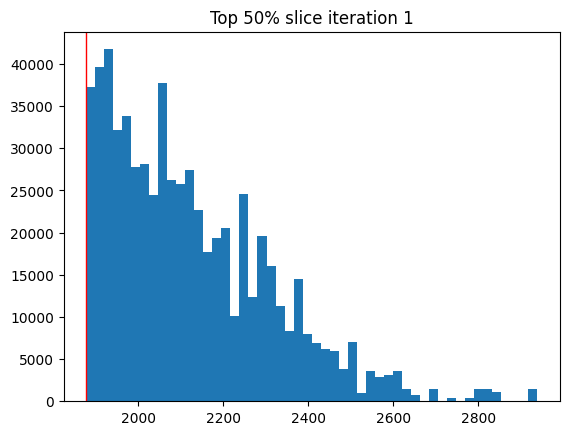

Iteration 1: 1282807 rows before slicing, 640982 rows after slicing, sliced on median which was 1877.72, percentage of players left  after slicing = 0.5


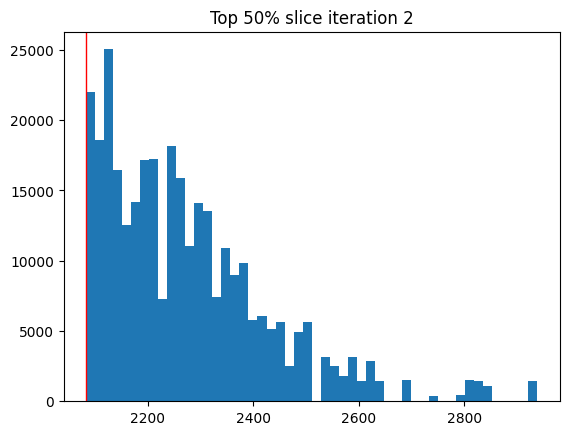

Iteration 2: 640982 rows before slicing, 320268 rows after slicing, sliced on median which was 2082.18, percentage of players left  after slicing = 0.25


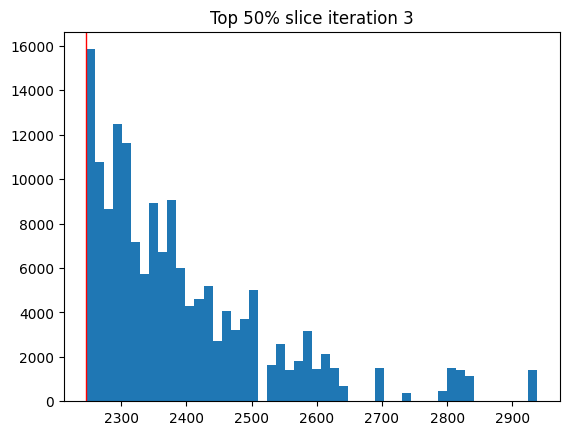

Iteration 3: 320268 rows before slicing, 159953 rows after slicing, sliced on median which was 2245.41, percentage of players left  after slicing = 0.125


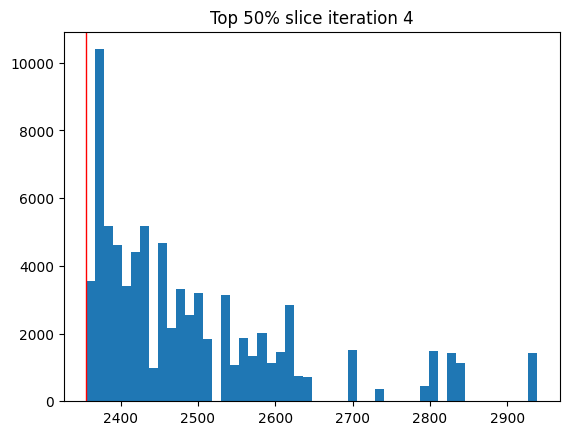

Iteration 4: 159953 rows before slicing, 79541 rows after slicing, sliced on median which was 2355.20, percentage of players left  after slicing = 0.062


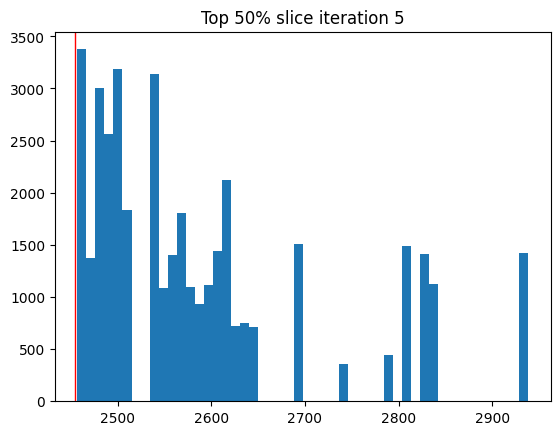

Iteration 5: 79541 rows before slicing, 39442 rows after slicing, sliced on median which was 2454.25, percentage of players left  after slicing = 0.031


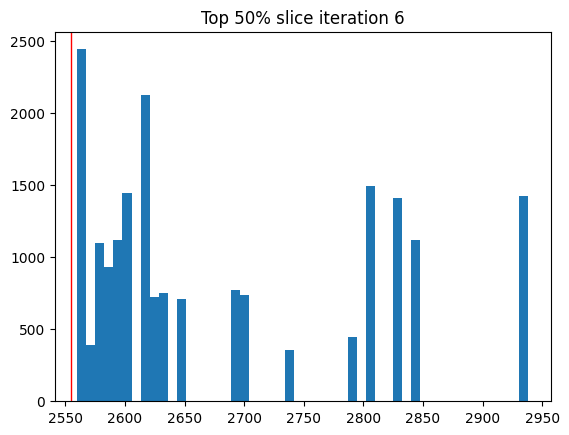

Iteration 6: 39442 rows before slicing, 19502 rows after slicing, sliced on median which was 2555.15, percentage of players left  after slicing = 0.015


In [1544]:
# Start with the full dataset
subset = full_df.copy()
starting_rows = len(subset)
print(len(subset))

for i in range(1, 7):
    # median of current subset
    q = np.quantile(subset['best_elo_reached'], 0.5)
    rows_before_slice = len(subset)
    
    # cut top 50% 
    subset = subset[subset['best_elo_reached'] > q]
    
    plt.figure()
    plt.hist(subset['best_elo_reached'], bins=50)
    plt.axvline(q, color='red', linewidth=1)
    plt.title(f"Top 50% slice iteration {i}")
    plt.show()
    
    # Optional: print info
    print(f"Iteration {i}: {rows_before_slice} rows before slicing, {len(subset)} rows after slicing, sliced on median which was {q:.2f}, percentage of players left  after slicing = {round(len(subset)/starting_rows,3)}")

In [1545]:
# split into 6 equal bins
labels = range(6)
look_for_full_df_bins = full_df['best_elo_reached'].to_frame()
look_for_full_df_bins['binned_elo'] = pd.qcut(full_df['best_elo_reached'], q=6, labels=labels)

In [1546]:
look_for_full_df_bins.groupby('binned_elo')['best_elo_reached'].agg(['min', 'max', 'count', 'mean', 'std'])

C:\Users\Golbe\AppData\Local\Temp\ipykernel_4340\2975914888.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  look_for_full_df_bins.groupby('binned_elo')['best_elo_reached'].agg(['min', 'max', 'count', 'mean', 'std'])


,min,max,count,mean,std
binned_elo,,,,,
0,1454.306662,1584.436582,213823,1523.249651,26.541719
1,1584.484432,1749.827600,213977,1672.512854,47.824625
2,1749.857687,1877.719958,214025,1814.183325,36.860225
3,1877.838597,2005.711319,213435,1937.937202,35.943897
4,2005.887175,2184.902003,214327,2086.846344,48.179674
5,2185.550864,2938.309846,213220,2348.236013,143.110747


Bin the ranks based on ranges based on the previous medians per bin:
- 2454+:          | all time greats
- 2355-2454:      | very good players
- 2245-2355:      | good players
- 2082-2245:      |  mid tier players
- 1878-2082:      | younger pro's and weak players
- 1878-0:         | very weak players

In [1547]:
# bin the data using the previously established data rounded to the nearest integer value

bins = [0, 1878, 2082, 2245, 2355, 2454, 3500]
labels = [0, 1, 2, 3, 4, 5]

full_df['binned_elo'] = pd.cut(
    full_df['best_elo_reached'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

In [1548]:
# alternative binning method that gives better results, but the q is arbitrary
#full_df['binned_elo'] = pd.qcut(full_df['best_elo_reached'], q=6, labels=[0,1,2,3,4,5])

In [1549]:
full_df.groupby('binned_elo')['best_elo_reached'].describe()

C:\Users\Golbe\AppData\Local\Temp\ipykernel_4340\2152497580.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  full_df.groupby('binned_elo')['best_elo_reached'].describe()


,count,mean,std,min,25%,50%,75%,max
binned_elo,,,,,,,,
0,642284.0,1670.176444,124.815899,1454.306662,1542.645889,1676.989716,1783.694003,1877.838597
1,319960.0,1974.035360,59.950233,1878.242906,1922.200132,1968.961432,2027.620748,2081.984248
2,158708.0,2154.972563,46.420834,2082.177952,2116.990733,2147.532685,2194.363589,2244.863438
3,81356.0,2292.862855,31.654937,2245.047370,2264.160226,2293.919204,2314.023337,2354.765317
4,40386.0,2396.144257,27.370878,2355.196150,2373.226770,2390.612108,2419.574922,2452.888353
5,40113.0,2587.378809,126.569157,2454.245619,2493.535022,2546.481533,2618.821801,2938.309846


## Continue with normal pipeline

In [1550]:
# select all features to use in the prediction
print(len(full_df))
df_subset = full_df[selected_features]
print(len(df_subset))

1282807
1282807


In [1551]:
df_subset.isna().sum().sort_values(ascending=False)

player_id                                 0
tourney_level                             0
match_num                                 0
player_age                                0
days_of_experience                        0
draw_size_rolling_med_10                  0
highest_finish_position_rolling_med_10    0
set_dominance_rolling_mean_10             0
tb_dominance_rolling_mean_10              0
mean_numb_rolling_mean_10                 0
mean_diff_rolling_mean_10                 0
mean_tb_numb_rolling_mean_10              0
mean_tb_diff_rolling_mean_10              0
elo                                       0
binned_elo                                0
dtype: int64

In [1552]:
# drop all values where nan because knn cannot deal with empty values
df_subset = df_subset.dropna()

In [1553]:
df_subset.isna().sum().sort_values(ascending=False)

player_id                                 0
tourney_level                             0
match_num                                 0
player_age                                0
days_of_experience                        0
draw_size_rolling_med_10                  0
highest_finish_position_rolling_med_10    0
set_dominance_rolling_mean_10             0
tb_dominance_rolling_mean_10              0
mean_numb_rolling_mean_10                 0
mean_diff_rolling_mean_10                 0
mean_tb_numb_rolling_mean_10              0
mean_tb_diff_rolling_mean_10              0
elo                                       0
binned_elo                                0
dtype: int64

From testing, the categorical columns tend to add little value to the prediction besides tourney_level. Removing them creates a better model for all metrics

In [1554]:
# # Print non numeric columns
print(len(df_subset))
numeric_cols = df_subset.select_dtypes(exclude=[np.number]).columns
print(numeric_cols)

# encode non numeric values
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop first to avoid multicollinearity
surface_encoded = encoder.fit_transform(df_subset[[
    # 'surface',
    #'player_country',
    'tourney_level'
    ]])
surface_df = pd.DataFrame(surface_encoded, 
                          columns=encoder.get_feature_names_out([
    #'surface',
    #'player_country',
    'tourney_level'
                                                                 ]),
                          index=df_subset.index)
df_encoded = pd.concat([df_subset.drop([
    #'surface',
    #'player_country',
    'tourney_level'
    ], axis=1), surface_df], axis=1)
#df_encoded = df_subset
print(len(df_encoded))

1282807
Index(['tourney_level', 'binned_elo'], dtype='object')
1282807


In [1555]:
excluded_player

121264

## Continue as normal

Instead of splitting on player_id, we will split on days of experience. This means that the model will train based on the amount of days specified, then after that it will predict the remaining dates left of all players

In [1556]:
if holdout == True:
    excluded_player_df = df_encoded.loc[df_encoded['player_id'] == excluded_player].copy()
    df_encoded = df_encoded.loc[df_encoded['player_id'] != excluded_player].copy()

# make sure that data is trained based on the cutoff points
train_df_cod = df_encoded[df_encoded['days_of_experience'] <= day_cutoff].copy()

test_df_cod = df_encoded[df_encoded['days_of_experience'] > day_cutoff].copy()

# get all ids of player who are still playing after the split
train_test_split_player_id_list = test_df_cod['player_id'].unique().tolist()

# remove isolated player from train test split
if excluded_player in train_test_split_player_id_list:
    train_test_split_player_id_list.remove(excluded_player)
else:
    pass

# take a sample
random.seed(42)
train_players = random.sample(train_test_split_player_id_list, int(0.8 * len(train_test_split_player_id_list)))

# get the remaining careers of players to be added in the train set
test_df_post_cod =  test_df_cod[test_df_cod['player_id'].isin(train_players)].copy()

# add the players and reset index
train_df = pd.concat([test_df_post_cod, train_df_cod])
train_df.reset_index(drop=True, inplace=True)

# make the test dataframe
test_df = test_df_cod[~test_df_cod['player_id'].isin(train_players)].copy()

# limit if wanted 
if max_number_of_days_cutoff != 0:
    test_df = test_df[test_df['days_of_experience'] < max_number_of_days_cutoff]

# make sure the holdout exists
if holdout != True:
    excluded_player_df = test_df[test_df['player_id'] == excluded_player].copy()

# prepare data
X_train = train_df.drop(columns=['binned_elo','elo'], axis=1) # Features for training without player_id
X_test = test_df.drop(columns=['binned_elo','elo'], axis=1) # Features for testing
y_train = train_df['binned_elo']
y_test = test_df['binned_elo']

In [1557]:
train_df

,player_id,match_num,player_age,days_of_experience,draw_size_rolling_med_10,highest_finish_position_rolling_med_10,set_dominance_rolling_mean_10,tb_dominance_rolling_mean_10,mean_numb_rolling_mean_10,mean_diff_rolling_mean_10,...,binned_elo,tourney_level_25,tourney_level_A,tourney_level_C,tourney_level_D,tourney_level_F,tourney_level_G,tourney_level_M,tourney_level_O,tourney_level_S
0,100011,2,42.0,1161,64.0,17.0,0.500000,0.0,6.000000,1.166667,...,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100011,271,45.0,1981,64.0,17.0,0.514286,0.0,6.000000,1.342857,...,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100012,249,38.0,1099,64.0,17.0,0.488889,0.5,6.022222,1.244444,...,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100012,276,38.0,1099,64.0,17.0,0.466667,1.0,6.022222,1.377778,...,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100012,247,38.0,1106,64.0,17.0,0.444444,1.0,6.022222,1.377778,...,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107848,213496,102,20.0,49,32.0,17.0,0.560000,0.0,5.240000,-0.680000,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1107849,213523,111,23.0,0,32.0,13.0,0.550000,0.0,5.100000,-0.800000,...,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1107850,213608,359,16.0,0,32.0,9.0,0.500000,0.0,5.700000,0.050000,...,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1107851,213626,368,16.0,0,32.0,5.0,0.400000,0.0,5.400000,0.050000,...,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [1558]:
test_df

,player_id,match_num,player_age,days_of_experience,draw_size_rolling_med_10,highest_finish_position_rolling_med_10,set_dominance_rolling_mean_10,tb_dominance_rolling_mean_10,mean_numb_rolling_mean_10,mean_diff_rolling_mean_10,...,binned_elo,tourney_level_25,tourney_level_A,tourney_level_C,tourney_level_D,tourney_level_F,tourney_level_G,tourney_level_M,tourney_level_O,tourney_level_S
90,100033,283,32.0,1280,64.0,33.0,0.466667,1.000000,6.111111,1.222222,...,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
152,100049,7,34.0,2402,64.0,33.0,0.425000,1.000000,6.025000,1.075000,...,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
153,100049,21,35.0,2549,48.0,25.0,0.450000,1.000000,5.975000,1.025000,...,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
422,100098,293,29.0,1717,64.0,33.0,0.450000,0.000000,6.050000,0.850000,...,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
440,100101,292,26.0,1160,32.0,9.0,0.355556,1.000000,6.022222,0.533333,...,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1263477,210319,370,21.0,1113,32.0,5.0,0.520000,0.250000,5.720000,0.020000,...,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1263478,210319,378,21.0,1113,32.0,5.0,0.500000,0.250000,5.760000,0.120000,...,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1263479,210319,382,21.0,1113,32.0,5.0,0.480000,0.333333,5.720000,0.140000,...,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1263480,210319,384,21.0,1113,32.0,5.0,0.480000,0.333333,5.720000,0.100000,...,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [1559]:
# from sklearn.model_selection import GroupKFold, GridSearchCV
# from sklearn.pipeline import Pipeline

# # Subsample players from training data
# unique_players = train_df['player_id'].unique()
# n_players_sub = int(0.1 * len(unique_players))

# sub_players = np.random.choice(
#     unique_players,
#     size=n_players_sub,
#     replace=False
# )

# sub_df = df_encoded[df_encoded['player_id'].isin(sub_players)]

# sub_df_cod = sub_df[sub_df['days_of_experience'] <= day_cutoff].copy()

# sub_test_df_cod = sub_df[sub_df['days_of_experience'] > day_cutoff].copy()

# # get all ids of player who are still playing after the split
# sub_train_test_split_player_id_list = sub_test_df_cod['player_id'].unique().tolist()

# # take a sample
# sub_train_players = random.sample(sub_train_test_split_player_id_list, int(0.8 * len(sub_train_test_split_player_id_list)))

# # get the remaining careers of players to be added in the train set
# sub_test_df_post_cod =  sub_test_df_cod[sub_test_df_cod['player_id'].isin(sub_train_players)].copy()

# # add the players and reset index
# sub_train_df = pd.concat([sub_test_df_post_cod, sub_df_cod])
# sub_train_df.reset_index(drop=True, inplace=True)

# MAX_ROWS = 150_000

# if len(sub_train_df) > MAX_ROWS:
#     sub_train_df = (
#         sub_train_df
#         .sample(MAX_ROWS, random_state=42)
#         .sort_values(['player_id', 'days_of_experience'])
#     )

# # Prepare data
# X_sub = sub_train_df.drop(columns=['binned_elo', 'player_id'])
# y_sub = sub_train_df['binned_elo']
# groups_sub = sub_train_df['player_id']

# # Pipeline
# pipe = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('knn', KNeighborsClassifier())
# ])

# param_grid = {
#     'knn__n_neighbors': range(1, 50,1),
#     'knn__weights':[
#         #'uniform',
#         'distance'
#                     ]
# }

# # Group-aware CV
# gkf = GroupKFold(n_splits=3)

# grid = GridSearchCV(
#     pipe,
#     param_grid,
#     cv=gkf,
#     return_train_score=True,
#     verbose=2,
#     n_jobs=-1
# )

# # pass groups here
# grid.fit(X_sub, y_sub, groups=groups_sub)

In [1560]:
# mean_test_scores = grid.cv_results_['mean_test_score']
# std_test_scores = grid.cv_results_['std_test_score']
# mean_train_scores = grid.cv_results_['mean_train_score']

# # Filter GridSearchCV results for uniform weights
# uniform_mask = [w == 'uniform' for w in grid.cv_results_['param_knn__weights']]
# k_values_uniform = [k for k, keep in zip(grid.cv_results_['param_knn__n_neighbors'], uniform_mask) if keep]
# mean_train_uniform = mean_train_scores[uniform_mask]
# mean_test_uniform = mean_test_scores[uniform_mask]

# plt.figure(figsize=(10,6))
# plt.plot(k_values_uniform, mean_train_uniform, label='Train Accuracy', marker='o', color='orangered')
# plt.plot(k_values_uniform, mean_test_uniform, label='CV Accuracy', marker='o', color='seagreen')
# plt.xlabel("Number of Neighbours (k)")
# plt.ylabel("Accuracy")
# plt.title(f"KNN Train vs CV Accuracy (uniform weights) {years_cutoff} years")
# plt.legend()
# plt.show()

# # Compute differences between consecutive mean CV scores
# cv_diff = np.diff(mean_test_uniform)  # mean_test_uniform[i+1] - mean_test_uniform[i]

# plt.figure(figsize=(10,4))
# plt.bar(k_values_uniform[1:], cv_diff, color='skyblue')
# plt.xlabel("Number of Neighbours (k)")
# plt.ylabel("Change in CV Accuracy")
# plt.title(f"ΔCV Accuracy per K step ({years_cutoff} years)")
# plt.show()



In [1561]:
# mean_test_scores = grid.cv_results_['mean_test_score']
# std_test_scores = grid.cv_results_['std_test_score']
# mean_train_scores = grid.cv_results_['mean_train_score']

# # Filter GridSearchCV results for uniform weights
# uniform_mask = [w == 'distance' for w in grid.cv_results_['param_knn__weights']]
# k_values_uniform = [k for k, keep in zip(grid.cv_results_['param_knn__n_neighbors'], uniform_mask) if keep]
# mean_train_uniform = mean_train_scores[uniform_mask]
# mean_test_uniform = mean_test_scores[uniform_mask]

# plt.figure(figsize=(10,6))
# plt.plot(k_values_uniform, mean_train_uniform, label='Train Accuracy', marker='o', color='orangered')
# plt.plot(k_values_uniform, mean_test_uniform, label='CV Accuracy', marker='o', color='seagreen')
# plt.xlabel("Number of Neighbours (k)")
# plt.ylabel("Accuracy")
# plt.title(f"KNN Train vs CV Accuracy (distance weights) {years_cutoff} years")
# plt.legend()
# plt.show()


In [1562]:
# freeze all rolling features to make sure there is no leakage when predicting
# if we do not freeze woule be giving the model the most recent match data which it in theory would not have
freeze_features = ['match_num', 
'draw_size_rolling_med_10', 
'highest_finish_position_rolling_med_10', 
'set_dominance_rolling_mean_10', 
'tb_dominance_rolling_mean_10', 
'mean_numb_rolling_mean_10', 
'mean_diff_rolling_mean_10', 
'mean_tb_numb_rolling_mean_10', 
'mean_tb_diff_rolling_mean_10']

# make sure the tourney level features will be frozen as wel
freeze_features.extend(X_test.columns[X_test.columns.str.startswith('tourney_level_')].tolist())

# last row of each player in training to freeze
last_train_stats = X_train.groupby('player_id')[freeze_features].last().reset_index()

# join frozen stats into X_test on player_id
X_test = X_test.drop(columns=freeze_features)  # remove old values first
X_test = X_test.merge(last_train_stats, on='player_id', how='left')

# fill na values with lowest observed number
X_test[freeze_features] = X_test[freeze_features].fillna(X_train[freeze_features].min())

In [1563]:
# drop player_id as we do not need it anymore for splitting
X_test = X_test.drop(columns=['player_id'],axis=1)
X_train = X_train.drop(columns=['player_id'],axis=1)

# sort columns before scaling
X_train = X_train[sorted(X_train.columns)]
X_test = X_test[sorted(X_test.columns)]

# scale features to normalise
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [1564]:
# train
k_number = 31
knn = KNeighborsClassifier(n_neighbors=k_number,weights='distance')
knn.fit(X_train_scaled, y_train)

,n_neighbors,31
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [1565]:
# predict
y_pred = knn.predict(X_test_scaled)

# metrics
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

recall_per_class = recall_score(y_test, y_pred, labels=[0,1,2,3,4,5], average=None)
balanced_acc = recall_per_class.mean()

In [1566]:
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("Recall per class:", " ".join([f"{r:.4f}" for r in recall_per_class]))
print(f"Accuracy: {(accuracy_score(y_test,y_pred)):.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Balanced Accuracy: 0.2903
Recall per class: 0.8588 0.3488 0.1320 0.0992 0.1084 0.1949
Accuracy: 0.5365
Precision: 0.4992
Recall: 0.5365
F1 Score: 0.4980


In [1567]:
# # Check if there's overfitting
# #train_score = knn.score(X_train_scaled, y_train)
# sample_idx = np.random.choice(len(X_train_scaled), size=50000, replace=False)
# train_acc = (knn.predict(X_train_scaled[sample_idx]) == y_train.iloc[sample_idx]).mean()

In [1568]:
# print(f"Train accuracy: {train_acc:.4f}")
# print(f"Test accuracy: {(accuracy_score(y_test,y_pred)):.4f}")

In [1569]:
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
y_pred_str = [bin_labels[i] for i in y_pred]
y_test_str = [bin_labels[j] for j in y_test]

y_pred = pd.Series(y_pred)
results = X_test.reset_index(drop=True).copy()
results['true_elo_coded'] = y_test.reset_index(drop=True)
results['pred_elo_coded'] = y_pred
results['true_elo_coded'] = results['true_elo_coded'].astype(int)
results['pred_elo_coded'] = results['pred_elo_coded'].astype(int)
results['true_elo'] = y_test_str
results['pred_elo'] = y_pred_str
results['correct'] = results['true_elo'] == results['pred_elo']
results['number_of_bins_off'] = results['true_elo_coded'] - results['pred_elo_coded']

wrong_preds = results[results['correct'] == False]

len(wrong_preds)

80846

## Visualisations for whole dataset

In [1570]:
# convert days of experience into years of experience
cutoff_in_years = int(round(day_cutoff / 365.25,1))

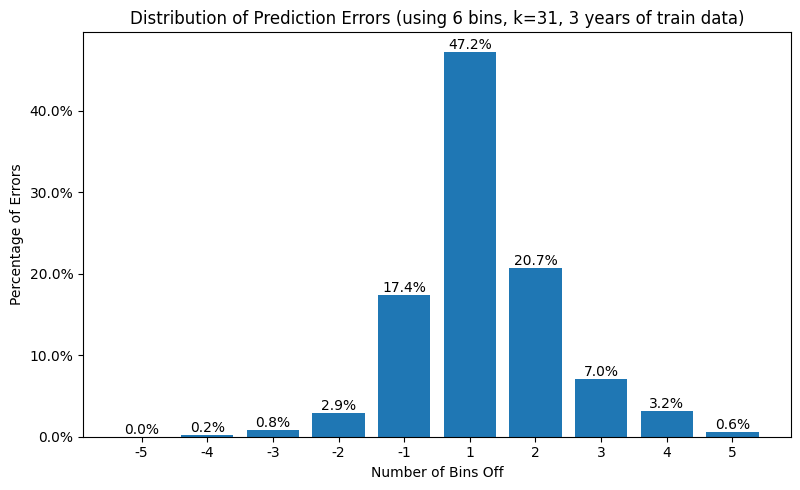

In [1571]:
counts = wrong_preds['number_of_bins_off'].value_counts().sort_index()/len(wrong_preds)

plt.figure(figsize=(8,5))
plt.xlabel("Number of Bins Off")
plt.ylabel("Percentage of Errors")
plt.title(f"Distribution of Prediction Errors (using {len(bins)-1} bins, k={k_number}, {cutoff_in_years} years of train data)")
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
bars = plt.bar(counts.index.astype(str), counts.values)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1%}",
        ha="center",
        va="bottom"
    )
#plt.show()

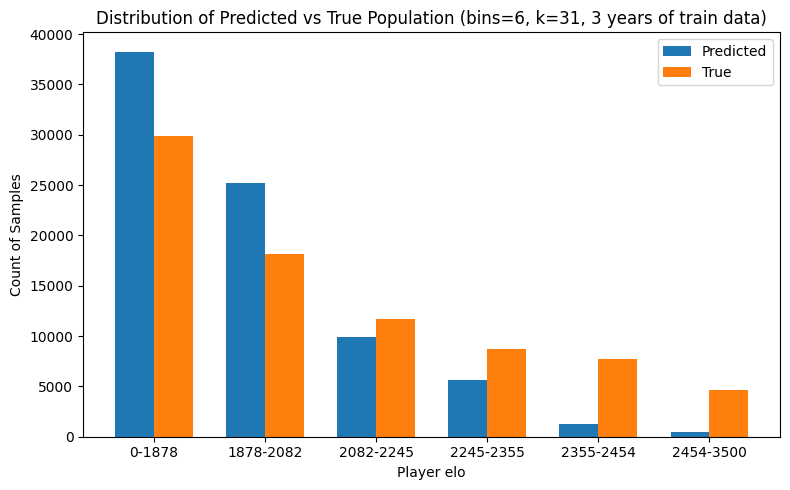

In [1572]:
# distribution of pred player_ranks and true player_ranks
pred_counts = wrong_preds['pred_elo_coded'].value_counts()
true_counts = wrong_preds['true_elo_coded'].value_counts()

x = np.arange(len(pred_counts))  # the x locations
width = 0.35  # width of the bars

plt.figure(figsize=(8,5))
plt.bar(x - width/2, pred_counts.values, width=width, label='Predicted')
plt.bar(x + width/2, true_counts.values, width=width, label='True')

plt.xlabel("Player elo")
plt.ylabel("Count of Samples")
plt.title(f"Distribution of Predicted vs True Population (bins={len(bins)-1}, k={k_number}, {cutoff_in_years} years of train data)")
plt.xticks(x, bin_labels)
plt.legend()
plt.tight_layout()
plt.show()


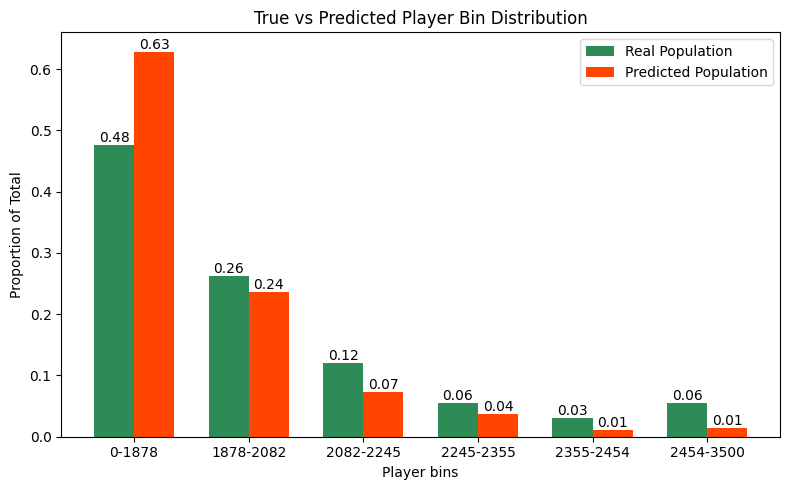

In [1573]:
# True distribution
counts = results['true_elo_coded'].value_counts().sort_index() / len(results)

# Predicted distribution
pred_counts = results['pred_elo_coded'].value_counts().sort_index() / len(results)

x = np.arange(len(counts))  # x positions
width = 0.35  # width of bars

plt.figure(figsize=(8,5))
bars_true = plt.bar(x - width/2, counts.values, width=width, label='Real Population', color='seagreen')
bars_pred = plt.bar(x + width/2, pred_counts.values, width=width, label='Predicted Population', color='orangered')

plt.xlabel("Player bins")
plt.ylabel("Proportion of Total")
plt.title("True vs Predicted Player Bin Distribution")
plt.xticks(x, bin_labels)
plt.legend()
plt.tight_layout()

# Add labels on top of the bars
for bar in bars_true:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha='center', va='bottom')

for bar in bars_pred:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha='center', va='bottom')

plt.show()


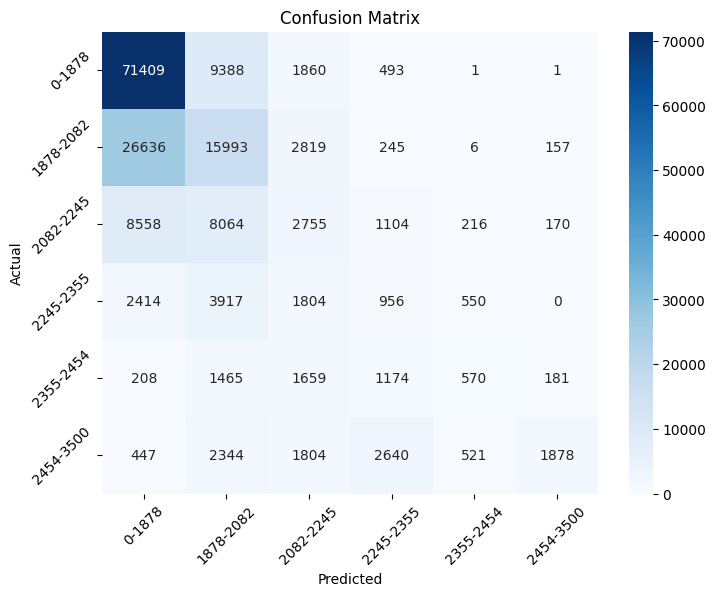

In [1574]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=bin_labels,yticklabels=bin_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.title("Confusion Matrix")
plt.show()

## Validation and visualisation for the excluded player

In [1575]:
if excluded_player:
    
    z_player_excluded = excluded_player_df['elo'] # get elo as a seperate value so model doesn't cheat

    # Compute true peak Elo for the excluded player
    true_max_elo_excluded = excluded_player_df['binned_elo'].max()

    # Attach it to every row
    excluded_player_df = excluded_player_df.copy()
    excluded_player_df['true_max_elo'] = true_max_elo_excluded

    # Construct test sets
    y_test_player_excluded = excluded_player_df['true_max_elo']
    X_player_excluded = excluded_player_df.drop(columns=['true_max_elo', 'binned_elo','elo','player_id'], axis=1)
    if len(X_player_excluded) > 0:
        # sort columns 
        X_player_excluded = X_player_excluded[sorted(X_player_excluded.columns)]

        X_player_excluded_scaled = scaler.transform(X_player_excluded)
        y_pred_player_excluded = knn.predict(X_player_excluded_scaled)
    else:
        pass
else:
    print('player_id was empty')

In [1576]:
# bin the elo of the player to be able to chart it
if excluded_player and len(X_player_excluded) > 0:
    player_excluded_rank_in_bins = pd.cut(
    z_player_excluded, 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

Percentage of times correctly guessed best rank for Oscar Jose Gutierrez (Accuracy): 0.5447897623400365


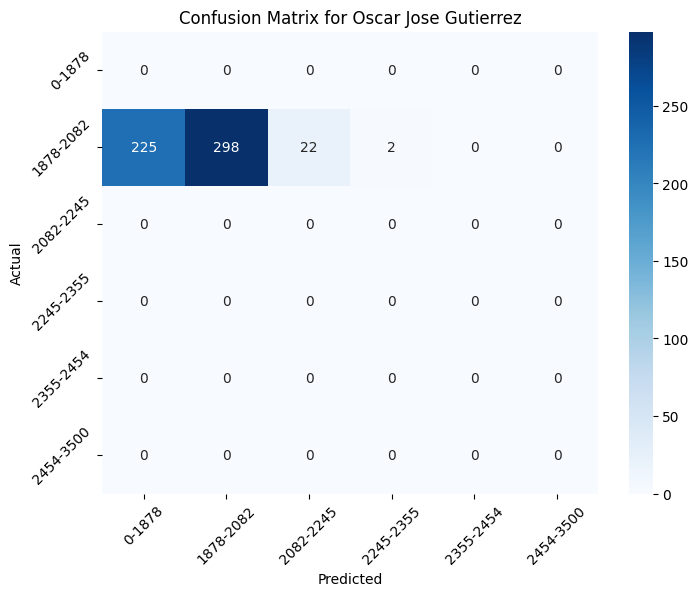

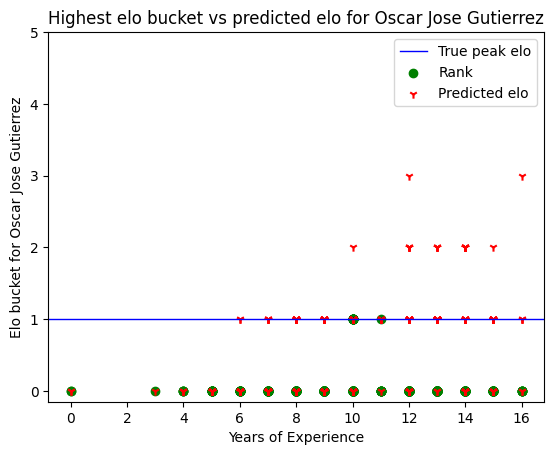

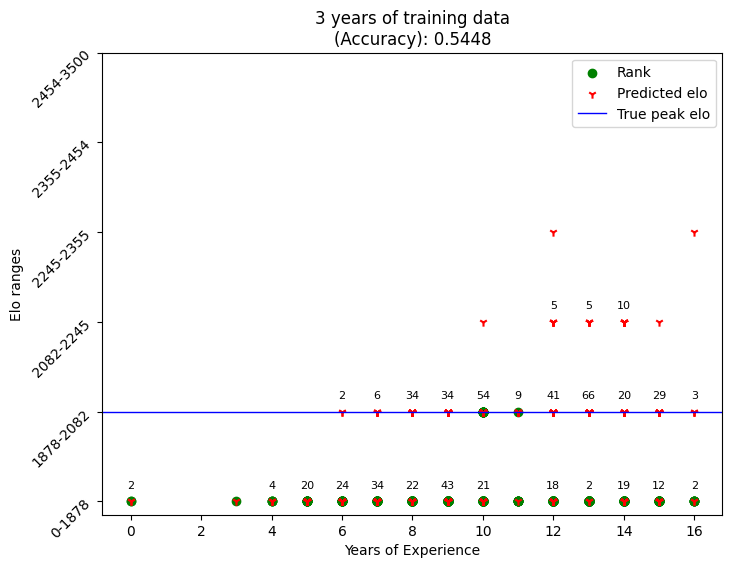

In [ ]:
if excluded_player and len(X_player_excluded) > 0:
    
    # Percentage of correctly predicted max elo
    guessed_correctly = (y_pred_player_excluded == y_test_player_excluded).mean()
    print(f"Percentage of times correctly guessed best rank for {name_chosen_player} (Accuracy): {guessed_correctly}")

    # confusion matrix for the player
    cm_xp = confusion_matrix(
    y_test_player_excluded, 
    y_pred_player_excluded, 
    labels=list(range(len(bin_labels)))  # ensures 0,1,2,3,4,5 all appear
    )

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_xp, annot=True, fmt="d", cmap="Blues",xticklabels=bin_labels,yticklabels=bin_labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {name_chosen_player}")
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.show()

    # create a dataframe of the results
    excluded_player_results = pd.DataFrame({
        'predicted_peak_elo_encoded':y_pred_player_excluded,
        'true_peak_elo_encoded':y_test_player_excluded,
        'correctly_predicted':y_pred_player_excluded==y_test_player_excluded
        })
    # merge the results with the x too get a full view and be able to visualise it
    excluded_player_final = pd.concat([X_player_excluded,excluded_player_results,player_excluded_rank_in_bins],axis=1)

    # bin the days of experience to reduce the data points on the graph and create a career year column
    excluded_player_final['days_bin'] = (excluded_player_final['days_of_experience'] // 30) * 30
    excluded_player_final['career_year'] = (excluded_player_final['days_of_experience'] // 365.25)

    # show predicted vs true as labled values (easier to look at than ranks)
    plt.axhline(y=excluded_player_final['true_peak_elo_encoded'].iloc[-1], color='blue', linestyle='-', linewidth=1, label='True peak elo')
    plt.scatter(excluded_player_final['career_year'],excluded_player_final['elo'],color='green', label='Rank')
    plt.scatter(excluded_player_final['career_year'], excluded_player_final['predicted_peak_elo_encoded'], color='red', label='Predicted elo',marker='1')
    plt.xlabel('Years of Experience')
    plt.ylabel(f'Elo bucket for {name_chosen_player}')
    plt.title(f'Highest elo bucket vs predicted elo for {name_chosen_player}')
    plt.legend()
    ax = plt.gca()
    ax.set_yticks([0,1,2,3,4,5])
    ax.set_yticklabels([0,1,2,3,4,5])
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()

    # get the last value from days bin where the pred was wrong
    if 0 in excluded_player_final['correctly_predicted'].to_list():
        last_wrong_pred_day_plus_30 = excluded_player_final[excluded_player_final['correctly_predicted'] == 0][['days_bin']].iloc[-1,0]+30
        zoomed_excluded_player_df = excluded_player_final[excluded_player_final['days_bin'] <= last_wrong_pred_day_plus_30]
    else:
        zoomed_excluded_player_df = excluded_player_final.copy()
    # 
    df = zoomed_excluded_player_df[['career_year', 'predicted_peak_elo_encoded','elo']].copy()
    counts = df.groupby(['career_year', 'predicted_peak_elo_encoded']).size().reset_index(name='count')
    
    plt.figure(figsize=(8, 6))
    plt.xlabel('Years of Experience')
    plt.ylabel(f'Elo ranges')
    plt.title(f'{years_cutoff} years of training data\n(Accuracy): {guessed_correctly:.4f}')
    plt.scatter(zoomed_excluded_player_df['career_year'],zoomed_excluded_player_df['elo'],color='green', label='Rank',marker='o')
    plt.scatter(zoomed_excluded_player_df['career_year'], zoomed_excluded_player_df['predicted_peak_elo_encoded'],color='red',label='Predicted elo',marker='1')
    
    plt.axhline(y=zoomed_excluded_player_df['true_peak_elo_encoded'].iloc[-1], color='blue', linestyle='-', linewidth=1, label='True peak elo')

    # create labels for places where points overlap
    for _, row in counts.iterrows():
        if row['count'] > 1:
            plt.text(row['career_year'], row['predicted_peak_elo_encoded']+0.18, str(int(row['count'])),
                    fontsize=8, ha='center', va='center')
    
    # make sure that the ticks are full integers
    ax = plt.gca()
    ax.set_yticks([0,1,2,3,4,5])
    ax.set_yticklabels(bin_labels)
    plt.yticks(rotation=45, ha='right')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend()
    if holdout == True:
        plt.savefig(f"C:/CMI-DataScience-Project/graphs and lineage/{years_cutoff} years/{years_cutoff} years {name_chosen_player} holdout.png")
    else:
        plt.savefig(f"C:/CMI-DataScience-Project/graphs and lineage/{years_cutoff} years/{years_cutoff} years {name_chosen_player}.png")
    plt.show()
else:
    fig = plt.figure(figsize=(8, 6))  # set size if needed
    plt.axis('off')                   # remove axes
    if holdout == True:
        plt.savefig(f"C:/CMI-DataScience-Project/graphs and lineage/{years_cutoff} years/{years_cutoff} years {name_chosen_player} holdout.png")
    else:
        plt.savefig(f"C:/CMI-DataScience-Project/graphs and lineage/{years_cutoff} years/{years_cutoff} years {name_chosen_player}.png")
    plt.close(fig)